In [1]:
import math
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy
import xarray as xr
from scipy.stats import kendalltau
import seaborn as sns
from scipy.stats.mstats import theilslopes
import geopandas as gpd


In [2]:
# Store site metadata (site number, site name, catchment number, NZTME, NZTMN)
metadata_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/metadata/40_50yr_sites.csv')
metadata_df.set_index('Number',inplace=True)

flow_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/flows/seasonal/50yrs/new_full_records.csv')
flow_df.date = pd.to_datetime(flow_df.date)
flow_df.set_index('date', inplace=True)

# define alpha and numeric season order
seasons_a = ['Winter','Spring','Summer','Autumn']
seasons_n = [6,9,12,3]

colors = ['red','blue','green','yellow']
markers = ['o','d','p','^']


In [3]:
winter = {1: [1316, 3506, 46618, 46651, 4901, 9301],
          2: [1043427, 1043428, 1043461, 1043466, 15408, 15410, 16501, 32503, 9205,
                       21412, 21801, 23104, 29224, 29808, 33117, 33316, 33347, 36001, 43472],
          3: [52916, 57009, 60114, 64602, 65104, 71116, 71120, 71123, 71129, 
              71132, 71135, 75232, 75288, 75292, 77505, 78625, 79704, 79713, 93203, 95101],
          4: [60104, 62105, 64610, 68001, 68806, 69621, 73501, 62103], 
         }

winter_names = {1: 'Northland',2: 'Central North Island',3:'West South Island',4:'East South Island'}
                   
summer = {1: [1043427, 1043428, 1043461, 1316, 15410, 16501, 21412, 21801, 23104, 32503, 
              33316, 3506, 43472, 46618, 46651, 4901, 9205, 9301, 15408],
          2: [1043466, 29224, 29808, 33117, 33347, 36001],
          3: [60114, 64602, 65104, 71116, 71120, 71123, 71129, 71132, 71135, 75232, 
              75288, 75292, 77505, 78625, 79704, 79713, 93203, 95101,52916],
          4: [57009, 60104, 62103, 62105, 64610, 68001, 68806, 69621,73501]
          }

summer_names = {1:'Northland', 2:'South North Island', 3:'West South Island', 4:'East South Island'}

autumn = {1: [1043427, 1043428, 1043461, 1043466, 1316, 15408, 15410, 16501, 21412, 21801, 
              23104, 32503, 33316, 33347, 3506, 43472, 46618, 46651, 4901, 9205, 9301],
          2: [29224, 29808, 33117, 36001, 52916, 57009, 60104, 60114, 62103, 62105, 64602, 
              64610, 65104, 68001, 68806, 69621, 71116, 71120, 71123, 71129, 71132, 71135, 
              73501, 75232, 75288, 75292, 77505, 78625, 79704, 79713, 93203, 95101]
         }

autumn_names = {1:'North', 2:'South'}

spring = {1: [1043427, 1043428, 1316, 15408, 15410, 16501, 21412, 21801, 23104, 32503, 
              3506, 43472, 46618, 46651, 4901, 60104, 64610, 68001, 69621, 73501, 9205, 9301],
          2: [1043461, 1043466, 29224, 29808, 33117, 33316, 33347, 36001, 52916, 57009, 
              60114, 62103, 62105, 64602, 65104, 68806, 71116, 71120, 71123, 71129, 71132, 
              71135, 75232, 75288, 75292, 77505, 78625, 79704, 79713, 93203, 95101]
          }
spring_names = {1: 'East', 2: 'West'}

cluster_lists = {6:winter,9:spring,12:summer,3:autumn}
names_list = {6:winter_names,9:spring_names,12:summer_names,3:autumn_names}

In [4]:
fp = '/nesi/project/niwa00015/queenle/data/arcgis/'
file = 'NESTCAT_v2_NZTM.shp'
catchment_data = gpd.read_file(fp+file)
catchment_data = catchment_data.to_crs("EPSG:4326")

catchments_df = catchment_data.loc[catchment_data['SITE'].isin(flow_df.columns)]

subset_meta = metadata_df.loc[[int(s) for s in flow_df.columns]]
subset_meta.sort_values('gauge_lat', ascending = False, inplace=True)
subset_meta['number_label'] = np.arange(1,len(subset_meta)+1)
subset_meta['number_copy'] = subset_meta.index.values.tolist()

meta_df = gpd.GeoDataFrame(subset_meta, 
                           geometry=gpd.points_from_xy(x=subset_meta.gauge_lon, y=subset_meta.gauge_lat),
                           crs='EPSG:4326')

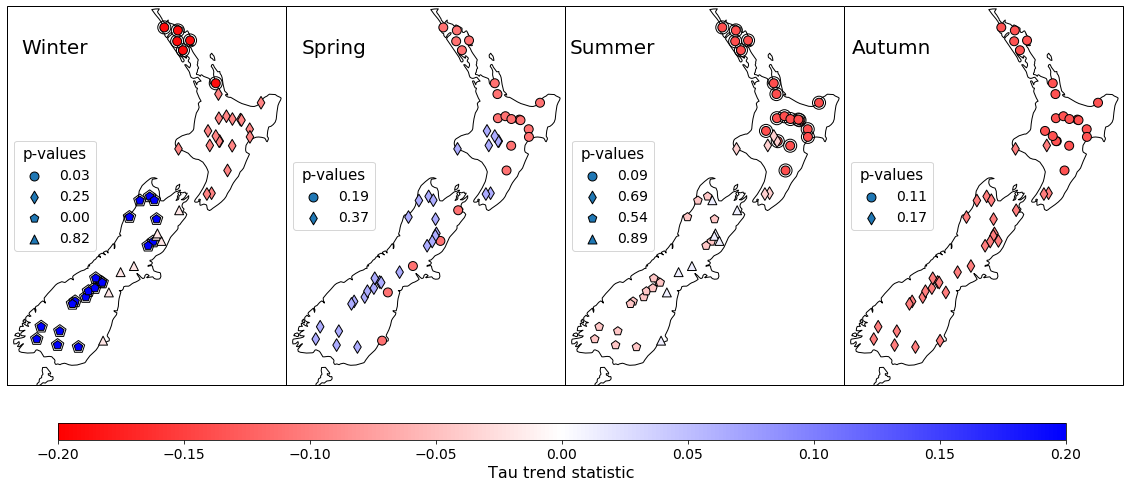

In [6]:
# Define the CartoPy CRS object.
crs = ccrs.Mercator()

# This can be converted into a `proj4` string/dict compatible with GeoPandas
crs_proj4 = crs.proj4_init
catchments_df_ae = catchments_df.to_crs(crs_proj4)
meta_df_ae = meta_df.to_crs(crs_proj4)

fig, axs = plt.subplots(1,4, subplot_kw={'projection': crs},figsize=(20,12))
axs = axs.flatten()

for i,s in enumerate(seasons_n):
    
    axs[i].coastlines(resolution='50m', color='black',linewidth=1,zorder = 1)
    axs[i].set_xlim([18500000,19900000])
    axs[i].set_ylim([-5950000,-4050000])
    axs[i].text(.17, .89, seasons_a[i], fontsize= 20, horizontalalignment="center", 
                verticalalignment="center", transform=axs[i].transAxes)

    cluster_dict = cluster_lists[s]
    cluster_names = names_list[s]

    df = flow_df[flow_df.index.month.isin([s])]

    for c in cluster_dict:

        cluster_df = df[[str(num) for num in cluster_dict[c]]]

        multiple_records_index = 0
        for j in range(len(cluster_df.index)):
            if np.count_nonzero(~np.isnan(cluster_df.iloc[j]))>2:
                multiple_records_index = j
                break

        cluster_df = cluster_df.iloc[multiple_records_index:]
        #cluster_df = (cluster_df - cluster_df['1979':'1999'].mean())/cluster_df['1979':'1999'].mean()
        cluster_df = (cluster_df - cluster_df.mean())/cluster_df.std()
        
        averaged_cluster = cluster_df.mean(axis=1,skipna=True)

        vals = averaged_cluster.values
        years = averaged_cluster.index.year.values

        coef, p = kendalltau(years,vals,nan_policy='omit')

        lons = []
        lats = []
        taus = []
        for site in cluster_df:
            lon = meta_df_ae.loc[int(site)].geometry.centroid.coords[0][0]
            lat = meta_df_ae.loc[int(site)].geometry.centroid.coords[0][1]
        
            if p < 0.1:
                axs[i].scatter(lon,lat, marker=markers[c-1],facecolors='none', edgecolors='black',s=170,zorder=50)

            lons.append(lon)
            lats.append(lat)
            taus.append(coef)

        im = axs[i].scatter(lons,lats,c=taus, cmap='bwr_r',marker=markers[c-1],vmin=-0.2,vmax=0.2,s=80,
                            label="{:.2f}".format(p),zorder=100, edgecolor='black')# if p > 0.1 else 'limegreen'
        
        #print(cluster_names[c] + ": " + str(coef) + ", " + str(p))


    axs[i].legend(loc='center left',title='p-values', title_fontsize=15, prop={'size': 14})
    
plt.subplots_adjust(wspace=0, hspace=0)

cax = fig.add_axes([0.16,0.22,.7,.02])
cbar = fig.colorbar(im, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=14)
cbar.set_label('Tau trend statistic',size=16)

plt.savefig('Figure6.png',dpi=300,bbox_inches='tight')
